# A disk–disk merger and its tidal bridge

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/11-disk-merger.ipynb)

Two disk galaxies on a close prograde passage throw off two of the most
recognisable structures in extragalactic astronomy: long **tidal tails**
streaming away from the far side of each disk, and a **bridge** of material
drawn across the gap between them. The Antennae and the Mice are the postcard
examples, and Toomre & Toomre (1972) showed — with a few hundred test particles
on a desk calculator's worth of compute — that plain gravity is enough.

The mechanism is a tidal one. During the passage the near side of each disk is
pulled toward the companion and the far side is left behind. Prograde material
stays in step with the perturber long enough to be drawn out into a thin,
coherent structure; the near-side material becomes the bridge, the far-side
material becomes the tail.

This notebook is also the first one here with **four live components**, and the
first where an external potential will not do.

**Runtime.** Around 5 minutes at the default resolution, about a minute with
`QUICK = True`.

## Setup

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy import potential
from galpy.df import isotropicHernquistdf
from galpy.potential import DoubleExponentialDiskPotential, HernquistPotential

import tambora
from tambora.simulation import Sim
from tambora.tools import galpydfsampler
from tambora.tools.util.units import G_KPC_KMS

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(17)

QUICK = False  # True -> quarter resolution, shorter run

tambora 0.1.0a1


## 1. Why the halo has to be live

Every galaxy notebook so far has attached its halo with `add_external_pot`,
as a rigid field. That is a good trade when the galaxy stays put: it costs no
particles and it cannot heat up.

It is the wrong trade here, and not by a little. A rigid external potential is
**nailed to the coordinate system**. It cannot travel with a galaxy, so a
merging pair would drag their disks out of their own haloes within the first
hundred megayears, and the haloes could not respond to each other at all. Worse,
a rigid halo cannot absorb orbital energy, so there would be no **dynamical
friction** — and dynamical friction is the entire reason a pair of galaxies
stops flying past one another and merges.

So both haloes become live particle components. That is four components in one
`Sim`, which is also a decent demonstration of why named components are worth
having.

### The halo profile: finite mass, and a truncation

We use a **Hernquist** halo rather than NFW. An NFW profile has formally
infinite mass, so "sample an NFW of mass $M$" is not a well-posed instruction —
the answer depends entirely on where you stop. A Hernquist profile has a finite
total mass and an exact isotropic distribution function, which is why it is the
conventional choice for merger initial conditions.

Finite mass is not the same as finite *extent*, though. A Hernquist sphere still
has a long tail, and sampling one directly puts a handful of particles hundreds
of kiloparsecs out — occasionally megaparsecs. Those particles do nothing
except inflate the tree's bounding box. So we truncate, and reassign masses so
that the mass inside the cut is right:

$$ M(<r) = M_{\rm tot}\,\frac{r^2}{(r+a)^2}. $$

In [3]:
M_DISK = 2.5e10  # disk mass, per galaxy [Msun]
H_R = 3.0  # disk scale length [kpc]
H_Z = 0.30  # disk scale height [kpc]
R_MAX = 5.0 * H_R

M_HALO = 2.5e11  # halo mass, per galaxy [Msun]
A_HALO = 12.0  # Hernquist scale radius [kpc]
R_CUT = 80.0  # truncate the halo here [kpc]
Q0 = 1.5  # Toomre Q

# galpy's HernquistPotential takes amp = 2 M_total.
halo_pot = HernquistPotential(amp=2 * M_HALO * u.Msun, a=A_HALO * u.kpc, ro=8.0, vo=220.0)
rho0 = M_DISK / (4.0 * np.pi * H_R**2 * H_Z)
disk_pot = DoubleExponentialDiskPotential(
    amp=rho0 * u.Msun / u.kpc**3, hr=H_R * u.kpc, hz=H_Z * u.kpc, ro=8.0, vo=220.0
)
for q in (halo_pot, disk_pot):
    q.turn_physical_on()
model = [disk_pot, halo_pot]

M_HALO_IN = M_HALO * R_CUT**2 / (R_CUT + A_HALO) ** 2
print(f"halo mass inside {R_CUT:.0f} kpc = {M_HALO_IN:.2e} Msun "
      f"({100 * M_HALO_IN / M_HALO:.0f}% of the total)")


def vc_of(pot, R):
    """Circular speed [km/s] at radii R [kpc], quietly."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.array(
            [float(potential.vcirc(pot, float(r) * u.kpc, ro=8.0, vo=220.0))
             for r in np.atleast_1d(R)]
        )


R_grid = np.linspace(0.05, R_MAX * 1.4, 140)
vc_grid = vc_of(model, R_grid)
Om_grid = vc_grid / R_grid
ka_grid = np.sqrt(
    np.clip(R_grid * np.gradient(Om_grid**2, R_grid) + 4.0 * Om_grid**2, 1e-12, None)
)
print(f"v_c(2 h_R) = {vc_of(model, 2 * H_R)[0]:.0f} km/s")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

halo mass inside 80 kp

### Building one galaxy

A disk in centrifugal + epicyclic equilibrium (as in
[example 08](08-ring-galaxy.ipynb)), plus a Hernquist halo sampled from its
exact isotropic DF. `spin` sets which way the disk turns; we work out the
required sign from the orbit itself in the next section, because both disks
must be **prograde** with respect to the encounter. That is the configuration
that produces the long tails, and getting the sign backwards is the single
easiest way to make this whole notebook show nothing.

In [4]:
def make_disk(n, spin=+1, seed=0):
    r = np.random.default_rng(seed)
    RR = np.linspace(0.0, R_MAX, 4000)
    cdf = 1.0 - (1.0 + RR / H_R) * np.exp(-RR / H_R)
    cdf /= cdf[-1]
    R = np.interp(r.random(n), cdf, RR)

    phi = r.uniform(0.0, 2.0 * np.pi, n)
    z = np.where(r.random(n) < 0.5, -1.0, 1.0) * (-H_Z * np.log(r.random(n)))
    pos = np.column_stack([R * np.cos(phi), R * np.sin(phi), z])

    vc = np.interp(R, R_grid, vc_grid)
    Om = np.interp(R, R_grid, Om_grid)
    ka = np.interp(R, R_grid, ka_grid)

    Sigma = M_DISK / (2.0 * np.pi * H_R**2) * np.exp(-R / H_R)
    sigma_R = Q0 * 3.36 * G_KPC_KMS * Sigma / ka
    sigma_phi = sigma_R * ka / (2.0 * Om)
    sigma_z = np.sqrt(2.0 * np.pi * G_KPC_KMS * Sigma * H_Z)

    drift = sigma_R**2 * (1.0 - ka**2 / (4.0 * Om**2) - 2.0 * R / H_R)
    v_phi = np.sqrt(np.clip(vc**2 + drift, 0.0, None)) + r.normal(0.0, sigma_phi)
    v_R = r.normal(0.0, sigma_R)

    vel = np.column_stack(
        [
            v_R * np.cos(phi) - spin * v_phi * np.sin(phi),
            v_R * np.sin(phi) + spin * v_phi * np.cos(phi),
            r.normal(0.0, sigma_z),
        ]
    )
    pos -= pos.mean(axis=0)
    vel -= vel.mean(axis=0)
    return pos, vel, np.full(n, M_DISK / n)


def make_halo(n, seed=0):
    """Hernquist halo from its exact isotropic DF, truncated at R_CUT."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = isotropicHernquistdf(pot=halo_pot, ro=8.0, vo=220.0)
        # Oversample: the truncation throws some away.
        p, v, _ = galpydfsampler(df, n=int(n * 1.6), m_total=M_HALO)
    keep = np.linalg.norm(p, axis=1) < R_CUT
    p, v = p[keep][:n], v[keep][:n]
    p -= p.mean(axis=0)
    v -= v.mean(axis=0)
    # Give the survivors the mass that actually belongs inside the cut.
    return p, v, np.full(len(p), M_HALO_IN / len(p))

## 2. The encounter orbit

Treat the two galaxies as point masses and put them on a **parabolic** relative
orbit with a chosen pericentre. For a parabola at separation $d$,

$$ v_{\rm rel} = \sqrt{\frac{2GM_{\rm tot}}{d}}, \qquad
   L = \sqrt{2GM_{\rm tot}\,r_p}, $$

which fixes the tangential and radial components. The galaxies are extended, not
points, so the real encounter will be somewhat deeper than this — but it is a
principled starting point rather than a guess.

In [5]:
D_START = 90.0  # initial separation [kpc]
R_PERI = 14.0  # target pericentre of the point-mass orbit [kpc]

M_GAL = M_DISK + M_HALO_IN  # mass per galaxy that actually participates
M_TOT = 2 * M_GAL

v_rel = np.sqrt(2 * G_KPC_KMS * M_TOT / D_START)
L_rel = np.sqrt(2 * G_KPC_KMS * M_TOT * R_PERI)
v_t = L_rel / D_START
v_r = -np.sqrt(max(v_rel**2 - v_t**2, 0.0))

print(f"M per galaxy (inside cut) = {M_GAL:.2e} Msun")
print(f"relative speed at {D_START:.0f} kpc = {v_rel:.1f} km/s")
print(f"  radial {v_r:.1f}, tangential {v_t:.1f} km/s")

# Equal masses -> each galaxy takes half the relative orbit, in opposite senses.
pos1 = np.array([-D_START / 2, 0.0, 0.0])
pos2 = np.array([+D_START / 2, 0.0, 0.0])
vel1 = np.array([-v_r / 2, +v_t / 2, 0.0])
vel2 = np.array([+v_r / 2, -v_t / 2, 0.0])
print(f"galaxy 1 at {pos1.round(1)} kpc, v = {vel1.round(1)} km/s")
print(f"galaxy 2 at {pos2.round(1)} kpc, v = {vel2.round(1)} km/s")

# Which way does the pair orbit? Derive the disks' spin from it rather than
# hard-coding a sign. Getting this backwards makes both disks RETROGRADE, and a
# retrograde encounter produces almost no tails at all -- the galaxies sail past
# each other as blobs and the notebook quietly demonstrates nothing.
L_orb_z = pos1[0] * vel1[1] - pos1[1] * vel1[0]
SPIN = int(np.sign(L_orb_z))
print(f"orbital L_z = {L_orb_z:+.0f} kpc km/s  ->  disk spin = {SPIN:+d} (prograde)")

M per galaxy (inside cut) = 2.14e+11 Msun
relative speed at 90 kpc = 202.3 km/s
  radial -185.9, tangential 79.8 km/s
galaxy 1 at [-45.   0.   0.] kpc, v = [92.9 39.9  0. ] km/s
galaxy 2 at [45.  0.  0.] kpc, v = [-92.9 -39.9   0. ] km/s
orbital L_z = -1795 kpc km/s  ->  disk spin = -1 (prograde)


## 3. Assemble four components and run

The disks and haloes have very different densities, so each gets its own
softening. A halo particle here is ~50 times more massive than a disk particle;
giving it disk-sized softening would let it scatter disk stars hard enough to
heat the disk artificially.

In [6]:
N_DISK = 4000 if QUICK else 14000
N_HALO = 3000 if QUICK else 10000

d1p, d1v, d1m = make_disk(N_DISK, spin=SPIN, seed=1)
d2p, d2v, d2m = make_disk(N_DISK, spin=SPIN, seed=2)
h1p, h1v, h1m = make_halo(N_HALO, seed=3)
h2p, h2v, h2m = make_halo(N_HALO, seed=4)

sim = Sim()
sim.add_particles("disk1", d1p + pos1, d1v + vel1, d1m)
sim.add_particles("halo1", h1p + pos1, h1v + vel1, h1m)
sim.add_particles("disk2", d2p + pos2, d2v + vel2, d2m)
sim.add_particles("halo2", h2p + pos2, h2v + vel2, h2m)

print(f"disk particle mass = {d1m[0]:.2e} Msun")
print(f"halo particle mass = {h1m[0]:.2e} Msun  "
      f"({h1m[0] / d1m[0]:.0f}x the disk particle)")
sim

disk particle mass = 1.79e+06 Msun
halo particle mass = 1.89e+07 Msun  (11x the disk particle)


Sim — not run
  48000 particles in 4 components, 4.28e+11 Msun total

  Components
  ┌───────┬───────────┬─────────────┐
  │ name  │ particles │ mass [Msun] │
  ├───────┼───────────┼─────────────┤
  │ disk1 │     14000 │    2.50e+10 │
  │ halo1 │     10000 │    1.89e+11 │
  │ disk2 │     14000 │    2.50e+10 │
  │ halo2 │     10000 │    1.89e+11 │
  └───────┴───────────┴─────────────┘

  External forces
    (none)

  Hooks
    (none)

In [7]:
T_END = 1.2 if QUICK else 1.8
DT = 5e-4
DT_OUT = 1e-2
EPS = {"disk1": 0.12, "halo1": 0.6, "disk2": 0.12, "halo2": 0.6}

sim.run(t_end=T_END, dt=DT, dt_out=DT_OUT, eps=EPS, theta=0.6)
print(f"\n|dE/E0| = {sim.monitor.drift['energy'][-1]:.2e}")


# Track each galaxy by its halo, which carries most of the mass and stays
# coherent while the disks are being torn into tails.
#
# Use the *median* position, not the mass-weighted mean. This matters more than
# it looks. Once an encounter starts stripping material, a minority of particles
# ends up spread over tens of kiloparsecs, and a mean is dragged a long way by
# them: with the mean, this run reports the two centres still 58 kpc apart at
# the end and looks like a pair that never merged. The median puts them 6 kpc
# apart -- they have merged, which is also what the density maps plainly show.
# A mean is the wrong summary statistic for a distribution with a tail.
def com(comp, t):
    c = getattr(sim, comp)
    return np.array([np.median(c.x(t=t)), np.median(c.y(t=t)), np.median(c.z(t=t))])


sep = np.array([np.linalg.norm(com("halo1", i) - com("halo2", i))
                for i in range(len(sim.times))])

# The *first* pericentre is what makes the bridge and the tails, and it is not
# the global minimum of this curve: if the pair merges, the deepest approach is
# the merger at the end. Walk down to the first local minimum instead, on a
# lightly smoothed curve so sampling noise cannot stop the walk early.
# Pad with edge values, not zeros: a "same" convolution zero-pads, which puts a
# fake dip at t=0 that the walk below would read as the first pericentre.
_sm = np.convolve(np.pad(sep, 2, mode="edge"), np.ones(5) / 5.0, mode="valid")
i_peri = 1
while i_peri < len(_sm) - 2 and _sm[i_peri + 1] <= _sm[i_peri]:
    i_peri += 1
t_peri = sim.times[i_peri]
print(f"first pericentre {sep[i_peri]:.1f} kpc at t = {t_peri:.2f} Gyr")

  0%|          | 0/3600 [00:00<?, ?it/s]

  0%|          | 2/3600 [00:00<03:02, 19.72it/s, |dE/E0|=0.00e+00]

  0%|          | 6/3600 [00:00<02:15, 26.59it/s, |dE/E0|=0.00e+00]

  0%|          | 10/3600 [00:00<02:05, 28.50it/s, |dE/E0|=0.00e+00]

  0%|          | 14/3600 [00:00<02:02, 29.22it/s, |dE/E0|=0.00e+00]

...

100%|█████████▉| 3593/3600 [02:14<00:00, 24.88it/s, |dE/E0|=3.08e-04]

100%|█████████▉| 3596/3600 [02:14<00:00, 24.85it/s, |dE/E0|=3.08e-04]

100%|█████████▉| 3599/3600 [02:14<00:00, 24.87it/s, |dE/E0|=3.08e-04]

100%|██████████| 3600/3600 [02:14<00:00, 26.78it/s, |dE/E0|=2.94e-04]


|dE/E0| = 2.94e-04
first pericentre 15.8 kpc at t = 0.36 Gyr


## 4. Bridge and tails

The two disks are drawn in different colours here, and that is the point rather
than decoration: it is the only way to see that the bridge contains material
from **both** galaxies, and which tail came from which disk. The haloes are left
out of the picture — they dominate the mass and would bury the structure.

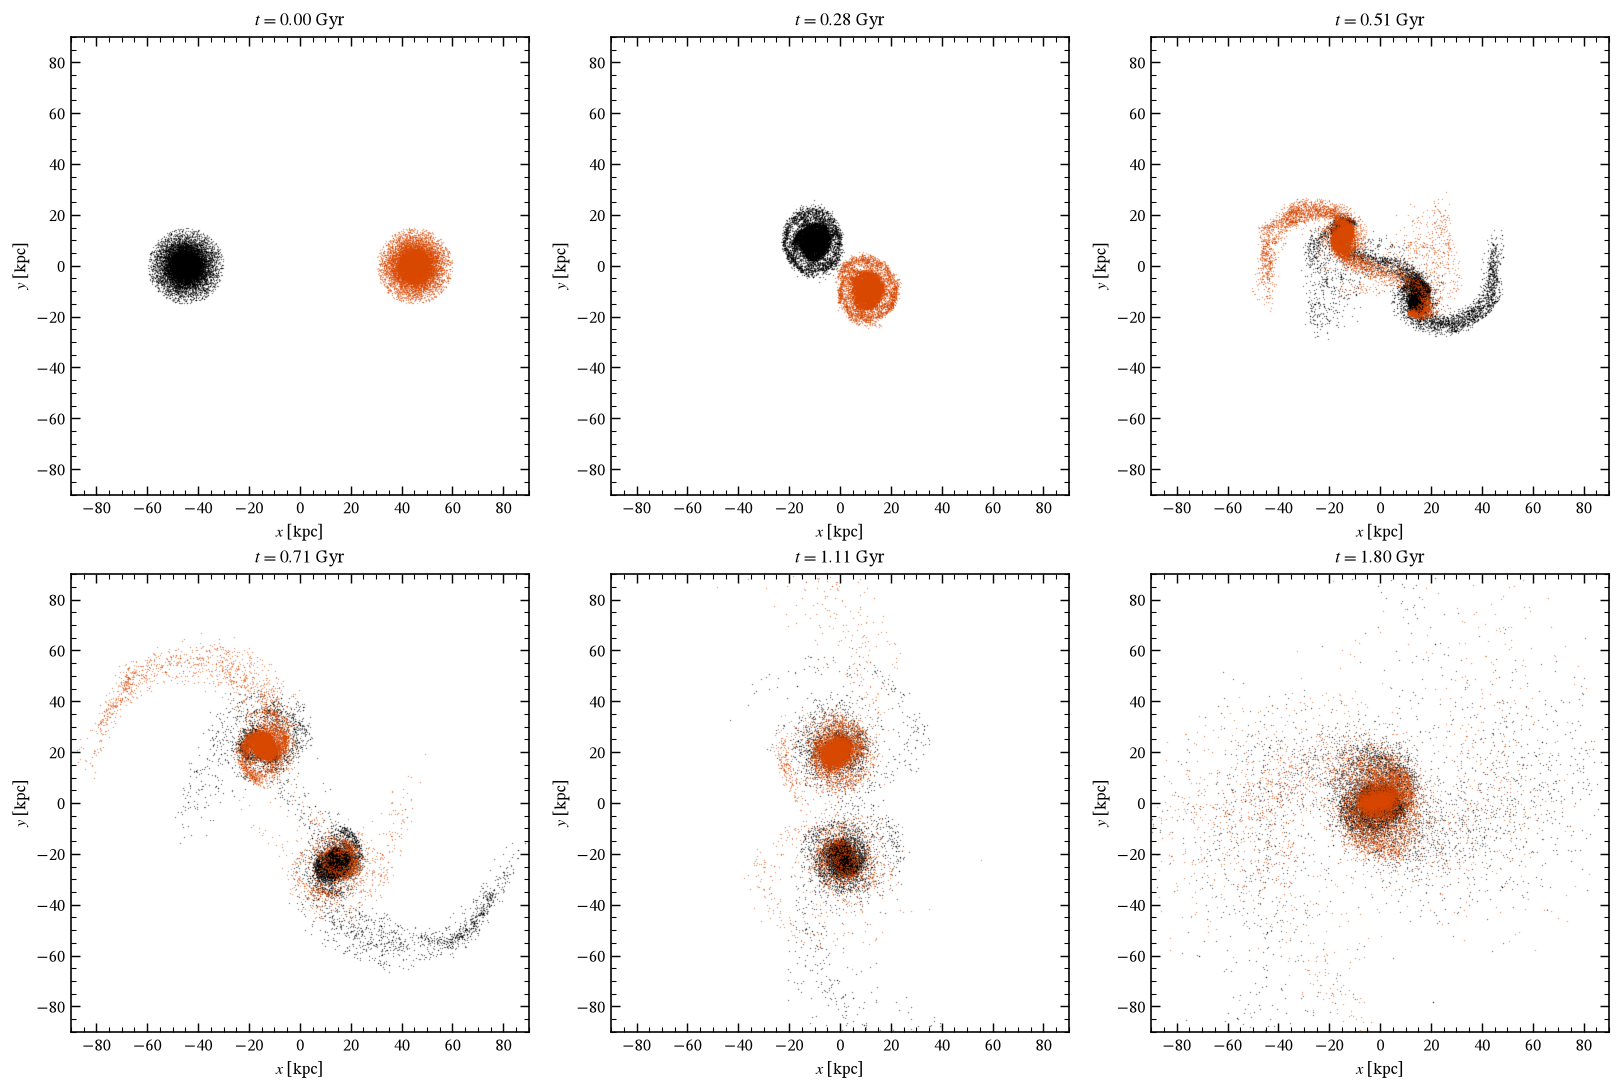

In [8]:
def show(ax, t, lim=90.0):
    ax.scatter(sim.disk1.x(t=t), sim.disk1.y(t=t), s=0.7, lw=0, c="k", alpha=0.4)
    ax.scatter(sim.disk2.x(t=t), sim.disk2.y(t=t), s=0.7, lw=0, c="#d94801", alpha=0.4)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("$x$ [kpc]")
    ax.set_ylabel("$y$ [kpc]")


# Uniform sampling wastes half the panels on the remnant and skips the bridge
# entirely. Anchor the times to pericentre instead.
t_show = [0.0, max(t_peri - 0.08, 0.0), t_peri + 0.15, t_peri + 0.35,
          min(t_peri + 0.75, sim.times[-1]), sim.times[-1]]
fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.4))
for ax, t in zip(axes.ravel(), t_show):
    show(ax, float(t))
    ax.set_title(f"$t = {t:.2f}$ Gyr")
fig.tight_layout()
plt.show()

## 5. The separation, and dynamical friction at work

The point-mass orbit we started from was parabolic, which formally means the
galaxies should separate forever. They do not — and the reason is the thing a
rigid halo could never have given us.

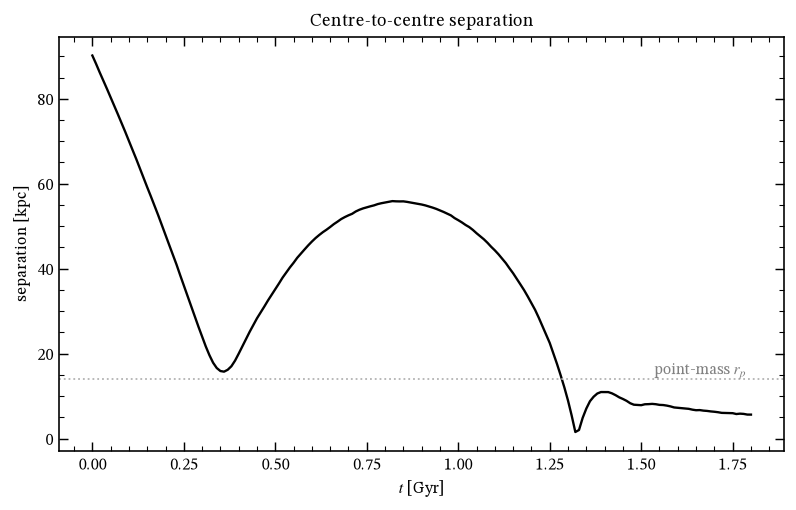

first pericentre: 15.8 kpc at t = 0.36 Gyr
  (point-mass prediction was 14.0 kpc)
closest approach overall: 1.6 kpc at t = 1.32 Gyr
separation at end: 5.7 kpc
  -> the two centres have converged: the galaxies have merged.
     The orbit decayed because the live haloes absorbed its energy.
     A rigid external halo could not have done this -- there would be
     no dynamical friction, and the pair would still be flying apart.


In [9]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(sim.times, sep, "k")
ax.axhline(R_PERI, c="0.7", ls=":", lw=1.0)
ax.text(sim.times[-1], R_PERI, " point-mass $r_p$ ", color="0.5",
        va="bottom", ha="right", fontsize=9)
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel("separation [kpc]")
ax.set_title("Centre-to-centre separation")
fig.tight_layout()
plt.show()

print(f"first pericentre: {sep[i_peri]:.1f} kpc at t = {t_peri:.2f} Gyr")
print(f"  (point-mass prediction was {R_PERI:.1f} kpc)")
print(f"closest approach overall: {sep.min():.1f} kpc at "
      f"t = {sim.times[int(np.argmin(sep))]:.2f} Gyr")
print(f"separation at end: {sep[-1]:.1f} kpc")
if sep[-1] < 0.15 * sep[0]:
    print("  -> the two centres have converged: the galaxies have merged.")
    print("     The orbit decayed because the live haloes absorbed its energy.")
    print("     A rigid external halo could not have done this -- there would be")
    print("     no dynamical friction, and the pair would still be flying apart.")
elif sep[-1] < sep[i_peri:].max():
    print("  -> the pair is falling back together: orbital energy has been lost")
    print("     to the haloes. A rigid halo could not have done this.")

## 6. Where the bridge came from

Take the material sitting between the two centres at the snapshot just after
pericentre, and ask which disk each particle started in. A *bridge* should be
mixed; a tail should not be.

In [10]:
i_br = min(i_peri + int(0.15 / DT_OUT), len(sim.times) - 1)
c1, c2 = com("halo1", i_br), com("halo2", i_br)
axis = c2 - c1
L = np.linalg.norm(axis)
u_ax = axis / L

frac, counts = [], []
for name in ("disk1", "disk2"):
    c = getattr(sim, name)
    rel = np.column_stack([c.x(t=i_br), c.y(t=i_br), c.z(t=i_br)]) - c1
    along = rel @ u_ax
    perp = np.linalg.norm(rel - np.outer(along, u_ax), axis=1)
    in_bridge = (along > 0.25 * L) & (along < 0.75 * L) & (perp < 12.0)
    counts.append(int(in_bridge.sum()))

print(f"at t = {sim.times[i_br]:.2f} Gyr, separation {L:.1f} kpc")
print(f"particles in the bridge region:")
print(f"  from disk 1: {counts[0]}")
print(f"  from disk 2: {counts[1]}")
if min(counts) > 0:
    print(f"  ratio {max(counts) / min(counts):.1f} : 1")
    print("  -> both disks contribute, which is what makes it a bridge rather")
    print("     than one galaxy's tail happening to point the right way.")

at t = 0.51 Gyr, separation 36.5 kpc
particles in the bridge region:
  from disk 1: 617
  from disk 2: 624
  ratio 1.0 : 1
  -> both disks contribute, which is what makes it a bridge rather
     than one galaxy's tail happening to point the right way.


## 7. The animation

70 frames, 1.5 MB


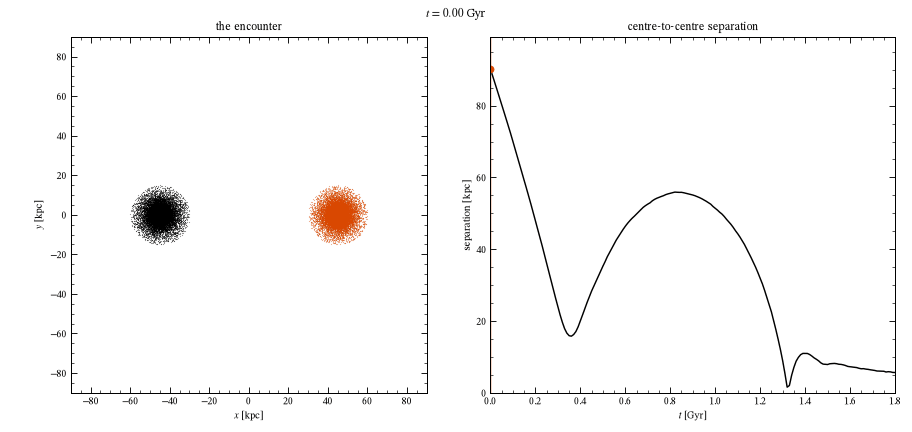

In [11]:
from IPython.display import Image  # noqa: E402
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402

t_anim = np.linspace(0.0, sim.times[-1], 70)
idx_anim = np.searchsorted(sim.times, t_anim).clip(0, len(sim.times) - 1)

LIM = 90.0
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.4, 5.4))

s1 = axL.scatter([], [], s=1.1, lw=0, c="k", alpha=0.45)
s2 = axL.scatter([], [], s=1.1, lw=0, c="#d94801", alpha=0.45)
axL.set_xlim(-LIM, LIM)
axL.set_ylim(-LIM, LIM)
axL.set_aspect("equal")
axL.set_xlabel("$x$ [kpc]")
axL.set_ylabel("$y$ [kpc]")
axL.set_title("the encounter")

axR.plot(sim.times, sep, "k", lw=1.3)
(vline,) = axR.plot([], [], c="#d94801", lw=1.3)
(dot,) = axR.plot([], [], "o", c="#d94801", ms=6)
axR.set_xlim(0, sim.times[-1])
axR.set_ylim(0, sep.max() * 1.1)
axR.set_xlabel("$t$ [Gyr]")
axR.set_ylabel("separation [kpc]")
axR.set_title("centre-to-centre separation")

ttl = fig.suptitle("")
fig.tight_layout()


def update(k):
    i = int(idx_anim[k])
    s1.set_offsets(np.c_[sim.disk1.x(t=i), sim.disk1.y(t=i)])
    s2.set_offsets(np.c_[sim.disk2.x(t=i), sim.disk2.y(t=i)])
    t = sim.times[i]
    vline.set_data([t, t], [0, axR.get_ylim()[1]])
    dot.set_data([t], [sep[i]])
    ttl.set_text(f"$t = {t:.2f}$ Gyr")
    return s1, s2, vline, dot, ttl


anim = FuncAnimation(fig, update, frames=range(len(idx_anim)), blit=False)
anim.save("disk_merger.gif", writer=PillowWriter(fps=6), dpi=80)
plt.close(fig)

from PIL import Image as PILImage, ImageSequence  # noqa: E402

_src = PILImage.open("disk_merger.gif")
_fr = [f.copy().convert("RGB").quantize(colors=64, method=PILImage.MEDIANCUT)
       for f in ImageSequence.Iterator(_src)]
_fr[0].save("disk_merger.gif", save_all=True, append_images=_fr[1:],
            duration=170, loop=0, optimize=True)
print(f"{len(_fr)} frames, "
      f"{__import__('os').path.getsize('disk_merger.gif') / 1e6:.1f} MB")

Image(filename="disk_merger.gif")

## 8. Caveats worth carrying forward

- **No gas.** Real merger bridges and tails are spectacular largely because gas
  shocks and lights up in them. This is a purely collisionless calculation, so
  compare morphology, not brightness.
- **The haloes are coarse.** Ten thousand particles per halo is enough to give
  dynamical friction roughly the right strength, not enough to trust the
  merger *timescale* to better than tens of per cent. If you care about when
  they coalesce, converge that number first.
- **Both disks are exactly prograde and coplanar.** That is the configuration
  that maximises tails, and it is not typical. Real encounters have arbitrary
  inclinations, and inclined disks give shorter, messier tails.
- **The truncation is a choice.** Cutting the halo at 80 kpc removes mass that
  would otherwise contribute at large separations. Push the cut outward if you
  care about the first approach rather than the merger itself.

## Summary

- A merging galaxy needs a **live** halo. A rigid external potential is fixed in
  space and gives you no dynamical friction, so the pair never merges.
- Prefer a profile with finite mass (Hernquist) for halo ICs, and truncate its
  tail explicitly rather than letting a few particles wander to a megaparsec.
- Per-component `eps` is not optional when particle masses differ by a factor of
  fifty.
- Colour the two disks separately: it is the only way to tell a bridge from a
  tail that happens to point the right way.